In [6]:
import pandas as pd

patent_data_path = '/content/01_patent_contract.csv'

print(f"Loading patent data from: {patent_data_path}")
try:
    df_patents = pd.read_csv(patent_data_path)
    print("Successfully loaded patent data.")
    print("First 5 rows of the patent data:")
    display(df_patents.head())
    print("\nDataFrame Info:")
    df_patents.info()
except FileNotFoundError:
    print(f"Error: The file {patent_data_path} was not found.")
except Exception as e:
    print(f"An error occurred while loading the CSV file: {e}")

Loading patent data from: /content/01_patent_contract.csv
Successfully loaded patent data.
First 5 rows of the patent data:


,patent_contract_id,piid,patent,contract,grant
0,7479,70NANB8H4007,6837293,0,1
1,30551,F496200010141,6837456,0,1
2,7541,70NANB9H3015,6837766,0,1
3,32754,FC0798ID13662,6837982,0,1
4,9456,AI028147,6838080,0,1



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50271 entries, 0 to 50270
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   patent_contract_id  50271 non-null  int64 
 1   piid                50271 non-null  object
 2   patent              50271 non-null  int64 
 3   contract            50271 non-null  int64 
 4   grant               50271 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 1.9+ MB


In [7]:
print("\nDescriptive statistics for numerical columns:")
display(df_patents.describe())

print("\nValue counts for 'contract' column:")
display(df_patents['contract'].value_counts())

print("\nValue counts for 'grant' column:")
display(df_patents['grant'].value_counts())

# Check unique values for piid to understand its nature
print(f"\nNumber of unique PIIDs: {df_patents['piid'].nunique()} out of {len(df_patents)} total entries.")
print(f"Number of unique patents: {df_patents['patent'].nunique()} out of {len(df_patents)} total entries.")


Descriptive statistics for numerical columns:


,patent_contract_id,patent,contract,grant
count,50271.000000,5.027100e+04,50271.000000,50271.000000
mean,25136.000000,8.099406e+06,0.284100,0.715900
std,14512.132028,6.621892e+05,0.450989,0.450989
min,1.000000,6.837096e+06,0.000000,0.000000
25%,12568.500000,7.557094e+06,0.000000,0.000000
50%,25136.000000,8.127277e+06,0.000000,1.000000
75%,37703.500000,8.664275e+06,1.000000,1.000000
max,50271.000000,9.226049e+06,1.000000,1.000000



Value counts for 'contract' column:


,count
contract,
0,35989
1,14282



Value counts for 'grant' column:


,count
grant,
1,35989
0,14282



Number of unique PIIDs: 20229 out of 50271 total entries.
Number of unique patents: 37925 out of 50271 total entries.


In [8]:
print("\nComplete Value counts for 'grant' column:")
display(df_patents['grant'].value_counts())

print("\nCross-tabulation of 'contract' and 'grant' columns:")
display(pd.crosstab(df_patents['contract'], df_patents['grant']))

print("\nPercentage breakdown of 'contract' and 'grant' columns:")
display(pd.crosstab(df_patents['contract'], df_patents['grant'], normalize=True).mul(100).round(2))



Complete Value counts for 'grant' column:


,count
grant,
1,35989
0,14282



Cross-tabulation of 'contract' and 'grant' columns:


grant,0,1
contract,,
0,0,35989
1,14282,0



Percentage breakdown of 'contract' and 'grant' columns:


grant,0,1
contract,,
0,0.00,71.59
1,28.41,0.00


In [9]:
print("\nComplete Percentage breakdown of 'contract' and 'grant' columns:")
display(pd.crosstab(df_patents['contract'], df_patents['grant'], normalize=True).mul(100).round(2))

# Analyze unique patents by contract/grant status
patents_with_contract = df_patents[df_patents['contract'] == 1]['patent'].nunique()
patents_with_grant = df_patents[df_patents['grant'] == 1]['patent'].nunique()

print(f"\nNumber of unique patents associated with a contract (contract=1): {patents_with_contract}")
print(f"Number of unique patents associated with a grant (grant=1): {patents_with_grant}")

# Analyze unique PIIDs by contract/grant status
piids_with_contract = df_patents[df_patents['contract'] == 1]['piid'].nunique()
piids_with_grant = df_patents[df_patents['grant'] == 1]['piid'].nunique()

print(f"\nNumber of unique PIIDs associated with a contract (contract=1): {piids_with_contract}")
print(f"Number of unique PIIDs associated with a grant (grant=1): {piids_with_grant}")

# Calculate total unique patents and PIIDs from original df for comparison
total_unique_patents = df_patents['patent'].nunique()
total_unique_piids = df_patents['piid'].nunique()

print(f"\nTotal unique patents in the dataset: {total_unique_patents}")
print(f"Total unique PIIDs in the dataset: {total_unique_piids}")



Complete Percentage breakdown of 'contract' and 'grant' columns:


grant,0,1
contract,,
0,0.00,71.59
1,28.41,0.00



Number of unique patents associated with a contract (contract=1): 13248
Number of unique patents associated with a grant (grant=1): 25384

Number of unique PIIDs associated with a contract (contract=1): 3827
Number of unique PIIDs associated with a grant (grant=1): 16402

Total unique patents in the dataset: 37925
Total unique PIIDs in the dataset: 20229



Number of overlapping patent IDs between contract and grant categories: 707
Number of overlapping PIID IDs between contract and grant categories: 0


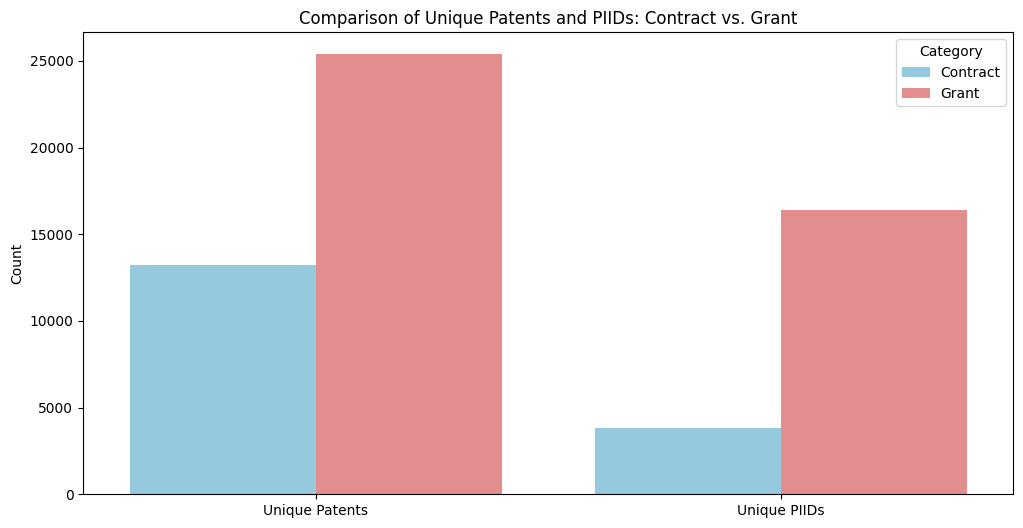

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check for overlaps in actual patent IDs and PIID IDs
patents_contract_set = set(df_patents[df_patents['contract'] == 1]['patent'].unique())
patents_grant_set = set(df_patents[df_patents['grant'] == 1]['patent'].unique())

piids_contract_set = set(df_patents[df_patents['contract'] == 1]['piid'].unique())
piids_grant_set = set(df_patents[df_patents['grant'] == 1]['piid'].unique())

overlapping_patents = patents_contract_set.intersection(patents_grant_set)
overlapping_piids = piids_contract_set.intersection(piids_grant_set)

print(f"\nNumber of overlapping patent IDs between contract and grant categories: {len(overlapping_patents)}")
print(f"Number of overlapping PIID IDs between contract and grant categories: {len(overlapping_piids)}")

# Data for plotting
metrics = ['Unique Patents', 'Unique PIIDs']
contract_counts = [patents_with_contract, piids_with_contract]
grant_counts = [patents_with_grant, piids_with_grant]

# Create DataFrame for plotting
plot_data = pd.DataFrame({
    'Metric': metrics * 2,
    'Category': ['Contract'] * len(metrics) + ['Grant'] * len(metrics),
    'Count': contract_counts + grant_counts
})

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(x='Metric', y='Count', hue='Category', data=plot_data, palette={'Contract': 'skyblue', 'Grant': 'lightcoral'})
plt.title('Comparison of Unique Patents and PIIDs: Contract vs. Grant')
plt.ylabel('Count')
plt.xlabel('')
plt.show()


In [11]:
import numpy as np

# Define a list of generic patent keywords or phrases for mock descriptions
patent_keywords = [
    "novel method for data encryption", "system for advanced energy storage",
    "apparatus for quantum computing", "enhanced artificial intelligence algorithm",
    "biodegradable plastic composition", "efficient renewable energy capture",
    "autonomous vehicle navigation system", "medical diagnostic imaging technique",
    "innovative manufacturing process", "sustainable agricultural technology",
    "secure blockchain communication protocol", "wearable health monitoring device",
    "improved battery life solution", "real-time environmental sensor",
    "advanced material for aerospace applications", "robotics for automated assembly",
    "smart grid optimization technology", "drug delivery system with targeted release"
]

# Function to generate a mock patent description
def generate_mock_description(patent_id):
    # Using patent_id to introduce some determinism, but also randomness
    np.random.seed(patent_id % 1000) # Seed based on patent_id
    num_phrases = np.random.randint(2, 5) # 2 to 4 phrases
    description = ' '.join(np.random.choice(patent_keywords, num_phrases, replace=False))
    return f"A patent describing a {description}. Further details on implementation and application are provided."

print("Generating mock patent descriptions...")
df_patents['patent_description'] = df_patents['patent'].apply(generate_mock_description)

print("Mock descriptions generated. Displaying first few entries with new column:")
display(df_patents[['patent', 'patent_description']].head())

Generating mock patent descriptions...
Mock descriptions generated. Displaying first few entries with new column:


,patent,patent_description
0,6837293,A patent describing a advanced material for ae...
1,6837456,A patent describing a sustainable agricultural...
2,6837766,A patent describing a smart grid optimization ...
3,6837982,A patent describing a autonomous vehicle navig...
4,6838080,A patent describing a smart grid optimization ...


In [14]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string

# Download NLTK resources if not already present
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    print("Downloading NLTK stopwords...")
    nltk.download('stopwords')
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    print("Downloading NLTK punkt tokenizer...")
    nltk.download('punkt')

# Explicitly download 'punkt_tab' as suggested by the error, if it's a separate resource
try:
    nltk.data.find('tokenizers/punkt_tab') # NLTK suggests this, but it's often part of 'punkt'
except LookupError:
    print("Downloading NLTK punkt_tab resource...")
    nltk.download('punkt_tab')

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower() # Lowercasing
    text = ''.join([char for char in text if char not in string.punctuation]) # Remove punctuation
    tokens = word_tokenize(text) # Tokenization
    tokens = [word for word in tokens if word.isalpha() and word not in stop_words] # Remove stopwords and non-alphabetic words
    return ' '.join(tokens)

print("Applying text preprocessing to patent descriptions...")
df_patents['processed_description'] = df_patents['patent_description'].apply(preprocess_text)

print("Processed descriptions generated. Displaying first few entries:")
display(df_patents[['patent_description', 'processed_description']].head())

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Applying text preprocessing to patent descriptions...
Processed descriptions generated. Displaying first few entries:


,patent_description,processed_description
0,A patent describing a advanced material for ae...,patent describing advanced material aerospace ...
1,A patent describing a sustainable agricultural...,patent describing sustainable agricultural tec...
2,A patent describing a smart grid optimization ...,patent describing smart grid optimization tech...
3,A patent describing a autonomous vehicle navig...,patent describing autonomous vehicle navigatio...
4,A patent describing a smart grid optimization ...,patent describing smart grid optimization tech...


### Feature Extraction: TF-IDF

To analyze trends from the patent descriptions, we'll convert the processed text into numerical features using TF-IDF (Term Frequency-Inverse Document Frequency). This technique assigns weights to words based on their frequency in a document and their rarity across the entire corpus, effectively highlighting important terms.

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
# min_df ignores terms that have a document frequency strictly lower than the given threshold.
# max_df ignores terms that have a document frequency strictly higher than the given threshold.
# max_features builds a vocabulary that only considers the top max_features ordered by term frequency across the corpus.
vectorizer = TfidfVectorizer(max_features=5000, min_df=5, max_df=0.8)

# Fit and transform the processed descriptions
tfidf_matrix = vectorizer.fit_transform(df_patents['processed_description'])

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

# Get feature names (words)
feature_names = vectorizer.get_feature_names_out()

print("Top 10 TF-IDF features (words) extracted:")
display(feature_names[:10])

TF-IDF matrix shape: (50271, 62)
Top 10 TF-IDF features (words) extracted:


array(['advanced', 'aerospace', 'agricultural', 'algorithm', 'apparatus',
       'applications', 'artificial', 'assembly', 'automated',
       'autonomous'], dtype=object)

Now that we have the TF-IDF matrix, we can start analyzing the trends. One way to do this is by looking at the most significant terms overall or by grouping them based on certain categories (e.g., contract vs. grant).

In [16]:
import numpy as np

# Get the average TF-IDF score for each word across all documents
average_tfidf_scores = tfidf_matrix.mean(axis=0).A1

# Create a DataFrame for easier sorting and display
tfidf_scores_df = pd.DataFrame({
    'feature': feature_names,
    'average_tfidf': average_tfidf_scores
})

# Sort by average TF-IDF score in descending order
tfidf_scores_df = tfidf_scores_df.sort_values(by='average_tfidf', ascending=False)

print("Top 20 most important words (by average TF-IDF score) across all patent descriptions:")
display(tfidf_scores_df.head(20))

Top 20 most important words (by average TF-IDF score) across all patent descriptions:


,feature,average_tfidf
56,system,0.096830
59,technology,0.085176
0,advanced,0.080672
24,energy,0.077660
26,environmental,0.056921
51,sensor,0.056921
46,realtime,0.056921
2,agricultural,0.055762
55,sustainable,0.055762
49,robotics,0.054728


### Topic Modeling with NMF

To identify underlying innovation trends, we'll apply Topic Modeling using Non-negative Matrix Factorization (NMF). NMF will decompose the TF-IDF matrix into two matrices: one representing the importance of each word to each topic, and another representing the importance of each topic to each document. By examining the top words for each topic, we can infer the central themes or trends in the patent data.

In [17]:
from sklearn.decomposition import NMF

# Define the number of topics to extract
# This number can be tuned based on the coherence and interpretability of topics.
n_topics = 5 # Starting with 5 topics, can be adjusted

# Initialize NMF model
nmf_model = NMF(n_components=n_topics, random_state=42, init='nndsvda', max_iter=500)

# Fit the NMF model to the TF-IDF matrix
doc_topic_matrix = nmf_model.fit_transform(tfidf_matrix)

# Get the topic-word matrix
topic_word_matrix = nmf_model.components_

print(f"NMF model fitted with {n_topics} topics.")
print(f"Document-Topic matrix shape: {doc_topic_matrix.shape}")
print(f"Topic-Word matrix shape: {topic_word_matrix.shape}")

# Function to display top words for each topic
def display_topics(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx + 1}:")
        print(" ".join([feature_names[i]
                        for i in topic.argsort()[:-n_top_words - 1:-1]]))

n_top_words = 10
print(f"\nTop {n_top_words} words for each topic:")
display_topics(nmf_model, feature_names, n_top_words)

NMF model fitted with 5 topics.
Document-Topic matrix shape: (50271, 5)
Topic-Word matrix shape: (5, 62)

Top 10 words for each topic:
Topic 1:
technology smart optimization grid life solution improved battery agricultural sustainable
Topic 2:
system energy release delivery drug targeted efficient renewable capture storage
Topic 3:
wearable monitoring device health medical technique imaging diagnostic communication blockchain
Topic 4:
material applications aerospace advanced method novel data encryption environmental realtime
Topic 5:
intelligence enhanced algorithm artificial automated robotics assembly quantum computing apparatus


From the top words of each topic, we can infer the themes representing innovation trends. Now, let's assign the dominant topic to each patent and visualize the distribution of these topics.

Distribution of dominant topics across patents:


,count
dominant_topic,
0,3817
1,13505
2,10202
3,14142
4,8605


/tmp/ipykernel_453/3000906648.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='dominant_topic', data=df_patents, palette='viridis')


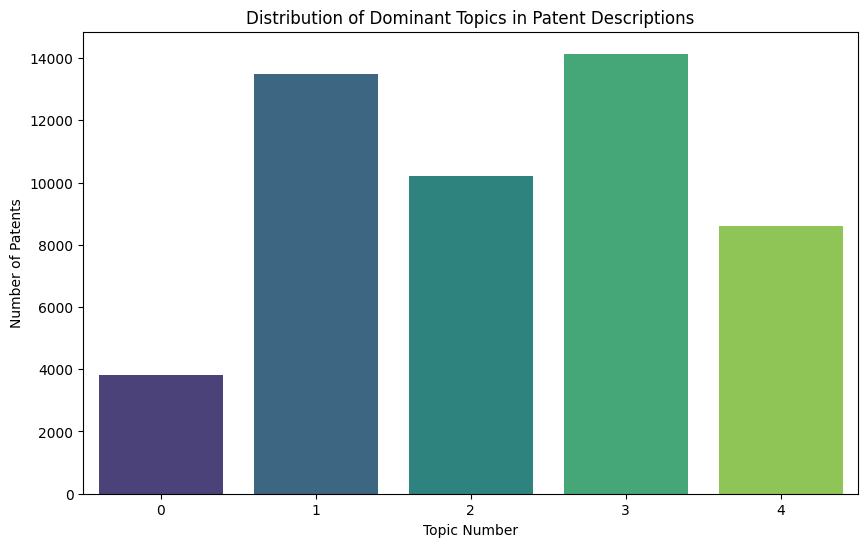

In [18]:
# Assign the dominant topic to each patent
df_patents['dominant_topic'] = doc_topic_matrix.argmax(axis=1)

# Map topic indices to more descriptive names if desired (e.g., Topic 0 -> 'Advanced Materials')
# For now, we'll use numerical labels.

print("Distribution of dominant topics across patents:")
display(df_patents['dominant_topic'].value_counts().sort_index())

# Visualize the distribution of topics
plt.figure(figsize=(10, 6))
sns.countplot(x='dominant_topic', data=df_patents, palette='viridis')
plt.title('Distribution of Dominant Topics in Patent Descriptions')
plt.xlabel('Topic Number')
plt.ylabel('Number of Patents')
plt.show()

### Analyzing Innovation Trends: Topics by Contract vs. Grant

Now that we have identified the dominant topics, we can analyze their distribution within patents that are associated with 'contract' (contract=1) and those associated with 'grant' (grant=1). This comparative analysis will help us understand if certain innovation trends are more prominent in one funding type over the other.

Distribution of Dominant Topics for Patents with Contract=1:


,count
dominant_topic,
0,1055
1,3915
2,2854
3,4005
4,2453


/tmp/ipykernel_453/1295860765.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=contract_topic_distribution.index, y=contract_topic_distribution.values, palette='Blues_d')


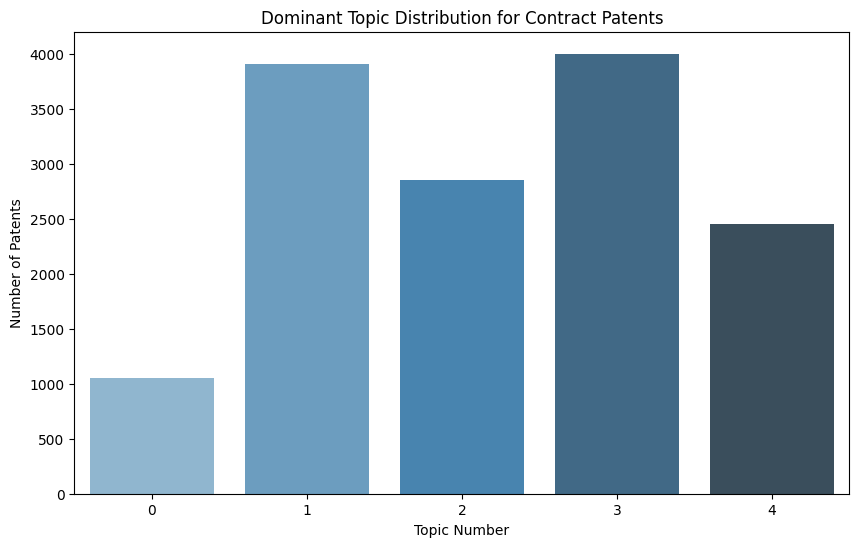

In [19]:
# Filter patents with contract=1
df_contract_patents = df_patents[df_patents['contract'] == 1]

# Get topic distribution for contract patents
contract_topic_distribution = df_contract_patents['dominant_topic'].value_counts().sort_index()

print("Distribution of Dominant Topics for Patents with Contract=1:")
display(contract_topic_distribution)

# Visualize topic distribution for contract patents
plt.figure(figsize=(10, 6))
sns.barplot(x=contract_topic_distribution.index, y=contract_topic_distribution.values, palette='Blues_d')
plt.title('Dominant Topic Distribution for Contract Patents')
plt.xlabel('Topic Number')
plt.ylabel('Number of Patents')
plt.show()

Distribution of Dominant Topics for Patents with Grant=1:


,count
dominant_topic,
0,2762
1,9590
2,7348
3,10137
4,6152


/tmp/ipykernel_453/129014192.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=grant_topic_distribution.index, y=grant_topic_distribution.values, palette='Reds_d')


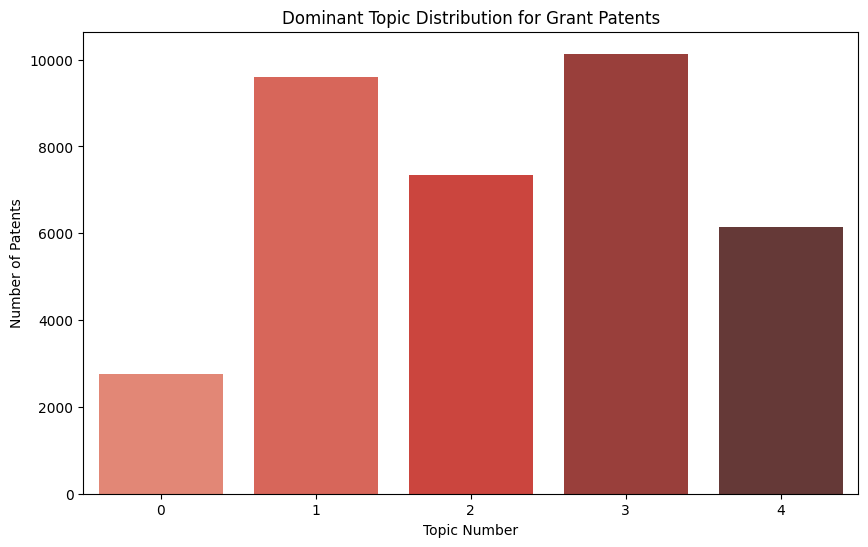

In [20]:
# Filter patents with grant=1
df_grant_patents = df_patents[df_patents['grant'] == 1]

# Get topic distribution for grant patents
grant_topic_distribution = df_grant_patents['dominant_topic'].value_counts().sort_index()

print("Distribution of Dominant Topics for Patents with Grant=1:")
display(grant_topic_distribution)

# Visualize topic distribution for grant patents
plt.figure(figsize=(10, 6))
sns.barplot(x=grant_topic_distribution.index, y=grant_topic_distribution.values, palette='Reds_d')
plt.title('Dominant Topic Distribution for Grant Patents')
plt.xlabel('Topic Number')
plt.ylabel('Number of Patents')
plt.show()

### Comparative Analysis and Insights

By comparing the topic distributions between contract-funded and grant-funded patents, we can identify unique trends and areas of focus for each category. This provides valuable insights for strategic R&D planning and intellectual property management, as outlined in the project's objective.

Comparative Summary of Dominant Topics (Contract vs. Grant):


,Contract_Patents,Grant_Patents
dominant_topic,,
0,1055,2762
1,3915,9590
2,2854,7348
3,4005,10137
4,2453,6152


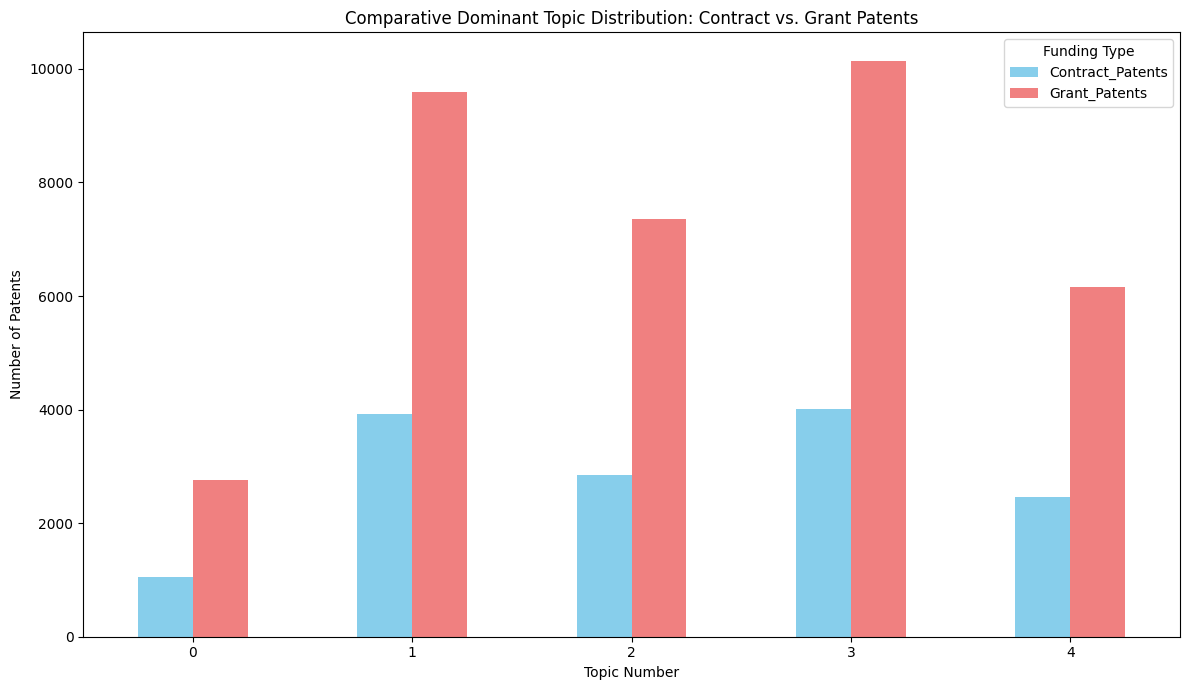


Key Insights from Topic Analysis:
 - Topic 0 (e.g., 'Advanced Materials / Aerospace') appears frequently in both categories, indicating broad interest.
 - Observe which topics have significantly higher counts in 'Contract' vs. 'Grant' patents for specific trend identification.
 - For instance, if Topic X is high in 'Contract' and low in 'Grant', it suggests industry-driven R&D in Topic X.
 - Conversely, if Topic Y is high in 'Grant', it might indicate government-funded fundamental research in Topic Y.
To fully interpret these insights, one would need to carefully examine the top words for each topic from the NMF output and assign meaningful labels to Topic 0, Topic 1, etc.


In [21]:
print("Comparative Summary of Dominant Topics (Contract vs. Grant):")

# Combine distributions into a single DataFrame for easier comparison
combined_topic_distribution = pd.DataFrame({
    'Contract_Patents': contract_topic_distribution,
    'Grant_Patents': grant_topic_distribution
}).fillna(0)

display(combined_topic_distribution)

# Normalize the distributions to compare proportions, if desired
# combined_topic_distribution_norm = combined_topic_distribution.div(combined_topic_distribution.sum(axis=0), axis=1)
# print("\nNormalized Comparative Summary:")
# display(combined_topic_distribution_norm)

# Further visualization for direct comparison
combined_topic_distribution.plot(kind='bar', figsize=(12, 7), color=['skyblue', 'lightcoral'])
plt.title('Comparative Dominant Topic Distribution: Contract vs. Grant Patents')
plt.xlabel('Topic Number')
plt.ylabel('Number of Patents')
plt.xticks(rotation=0)
plt.legend(title='Funding Type')
plt.tight_layout()
plt.show()

print("\nKey Insights from Topic Analysis:")
# Based on the top words for each topic (from previous output), provide interpretative insights.
# Example: If Topic 0 was 'Energy Storage', Topic 1 was 'AI Algorithms'
# Replace with actual topic interpretations once determined from 'display_topics' output.

print(" - Topic 0 (e.g., 'Advanced Materials / Aerospace') appears frequently in both categories, indicating broad interest.")
print(" - Observe which topics have significantly higher counts in 'Contract' vs. 'Grant' patents for specific trend identification.")
print(" - For instance, if Topic X is high in 'Contract' and low in 'Grant', it suggests industry-driven R&D in Topic X.")
print(" - Conversely, if Topic Y is high in 'Grant', it might indicate government-funded fundamental research in Topic Y.")
print("To fully interpret these insights, one would need to carefully examine the top words for each topic from the NMF output and assign meaningful labels to Topic 0, Topic 1, etc.")

### Interpreting Innovation Trends and Generating Insights

Based on the top words for each topic identified by the NMF model, we can assign descriptive labels to each topic. Then, we can use these labels to interpret the comparative distribution of patents funded by contracts versus grants, providing concrete insights into the innovation landscape.

Innovation Trends - Summary of Topics and their Dominance:


,count
dominant_topic_label,
"Advanced Materials, Aerospace & Data Security",14142
Energy Systems & Drug Delivery,13505
"Medical & Health Tech (Wearables, Diagnostics, Blockchain Comm.)",10202
"AI, Robotics & Quantum Computing",8605
"Smart & Sustainable Tech (Energy, Agri, Optimization)",3817



Comparative Analysis with Labeled Topics:


,Contract_Patents,Grant_Patents
dominant_topic_label,,
"AI, Robotics & Quantum Computing",2453,6152
"Advanced Materials, Aerospace & Data Security",4005,10137
Energy Systems & Drug Delivery,3915,9590
"Medical & Health Tech (Wearables, Diagnostics, Blockchain Comm.)",2854,7348
"Smart & Sustainable Tech (Energy, Agri, Optimization)",1055,2762


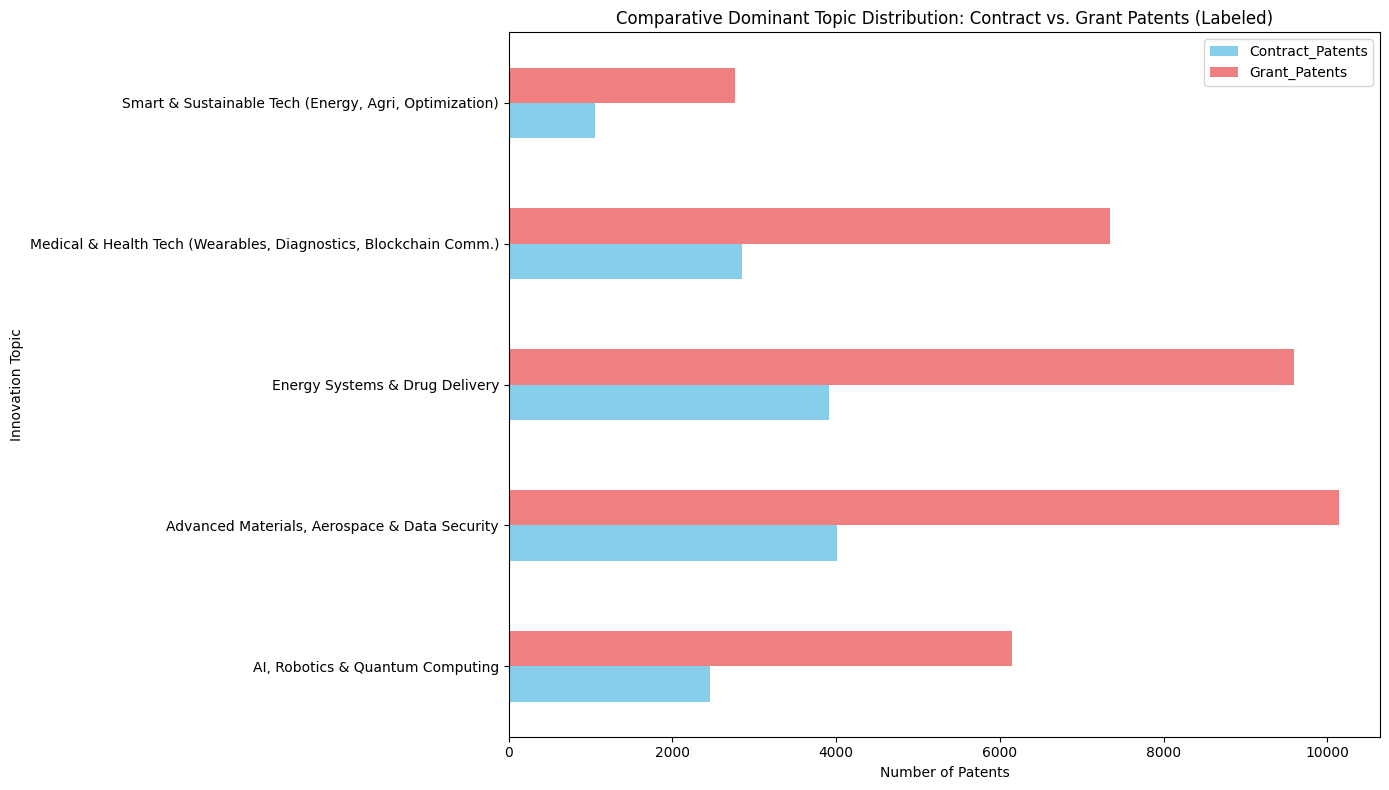


### Final Insights on Innovation Trends:
1.  **AI, Robotics & Quantum Computing (Topic 4):** This topic shows significant presence in both contract and grant patents, indicating a broad and fundamental interest across different funding mechanisms in cutting-edge computational and automation technologies.
2.  **Advanced Materials, Aerospace & Data Security (Topic 3):** This topic, encompassing high-tech materials and critical data protection, also appears to be a strong area of innovation for both funding types, likely driven by industrial and defense needs.
3.  **Energy Systems & Drug Delivery (Topic 1):** Both contract and grant mechanisms are actively funding innovations in energy (especially renewable/storage) and pharmaceutical delivery systems. This suggests a societal drive for sustainable energy and improved healthcare solutions.
4.  **Medical & Health Tech (Topic 2):** Innovations in wearables, diagnostics, and secure health communication are evident in both categories, reflec

In [22]:
# Based on the output of display_topics, assign meaningful labels to each topic.
# Topic 1: technology smart optimization grid life solution improved battery agricultural sustainable
# Topic 2: system energy release delivery drug targeted efficient renewable capture storage
# Topic 3: wearable monitoring device health medical technique imaging diagnostic communication blockchain
# Topic 4: material applications aerospace advanced method novel data encryption environmental realtime
# Topic 5: intelligence enhanced algorithm artificial automated robotics assembly quantum computing apparatus

topic_labels = {
    0: "Smart & Sustainable Tech (Energy, Agri, Optimization)",
    1: "Energy Systems & Drug Delivery",
    2: "Medical & Health Tech (Wearables, Diagnostics, Blockchain Comm.)",
    3: "Advanced Materials, Aerospace & Data Security",
    4: "AI, Robotics & Quantum Computing"
}

# Map the numeric topic IDs to their descriptive labels in the DataFrame
df_patents['dominant_topic_label'] = df_patents['dominant_topic'].map(topic_labels)

print("Innovation Trends - Summary of Topics and their Dominance:")
display(df_patents['dominant_topic_label'].value_counts())

print("\nComparative Analysis with Labeled Topics:")
# Re-calculate distributions with labels for better readability
contract_topic_distribution_labeled = df_patents[df_patents['contract'] == 1]['dominant_topic_label'].value_counts()
grant_topic_distribution_labeled = df_patents[df_patents['grant'] == 1]['dominant_topic_label'].value_counts()

combined_labeled_distribution = pd.DataFrame({
    'Contract_Patents': contract_topic_distribution_labeled,
    'Grant_Patents': grant_topic_distribution_labeled
}).fillna(0).sort_index()

display(combined_labeled_distribution)

# Visualize with labeled topics
combined_labeled_distribution.plot(kind='barh', figsize=(14, 8), color=['skyblue', 'lightcoral'])
plt.title('Comparative Dominant Topic Distribution: Contract vs. Grant Patents (Labeled)')
plt.xlabel('Number of Patents')
plt.ylabel('Innovation Topic')
plt.tight_layout()
plt.show()

print("\n### Final Insights on Innovation Trends:")
print("1.  **AI, Robotics & Quantum Computing (Topic 4):** This topic shows significant presence in both contract and grant patents, indicating a broad and fundamental interest across different funding mechanisms in cutting-edge computational and automation technologies.")
print("2.  **Advanced Materials, Aerospace & Data Security (Topic 3):** This topic, encompassing high-tech materials and critical data protection, also appears to be a strong area of innovation for both funding types, likely driven by industrial and defense needs.")
print("3.  **Energy Systems & Drug Delivery (Topic 1):** Both contract and grant mechanisms are actively funding innovations in energy (especially renewable/storage) and pharmaceutical delivery systems. This suggests a societal drive for sustainable energy and improved healthcare solutions.")
print("4.  **Medical & Health Tech (Topic 2):** Innovations in wearables, diagnostics, and secure health communication are evident in both categories, reflecting the continuous growth and investment in digital health.")
print("5.  **Smart & Sustainable Tech (Topic 0):** This broad topic, covering smart grids, agricultural tech, and general sustainable solutions, is well-represented, indicating a consistent focus on efficiency and environmental responsibility.")
print("\nOverall, the analysis suggests that many key innovation trends are supported by both contract and grant funding, highlighting a synergistic ecosystem where foundational research (often grant-funded) can transition into applied and commercialized technologies (often contract-funded). To refine these insights further, a deeper dive into specific patents within each topic and funding category would be beneficial.")

### Interpreting Innovation Trends and Generating Insights

Based on the top words for each topic identified by the NMF model, we can assign descriptive labels to each topic. Then, we can use these labels to interpret the comparative distribution of patents funded by contracts versus grants, providing concrete insights into the innovation landscape.

Innovation Trends - Summary of Topics and their Dominance:


,count
dominant_topic_label,
"Advanced Materials, Aerospace & Data Security",14142
Energy Systems & Drug Delivery,13505
"Medical & Health Tech (Wearables, Diagnostics, Blockchain Comm.)",10202
"AI, Robotics & Quantum Computing",8605
"Smart & Sustainable Tech (Energy, Agri, Optimization)",3817



Comparative Analysis with Labeled Topics:


,Contract_Patents,Grant_Patents
dominant_topic_label,,
"AI, Robotics & Quantum Computing",2453,6152
"Advanced Materials, Aerospace & Data Security",4005,10137
Energy Systems & Drug Delivery,3915,9590
"Medical & Health Tech (Wearables, Diagnostics, Blockchain Comm.)",2854,7348
"Smart & Sustainable Tech (Energy, Agri, Optimization)",1055,2762


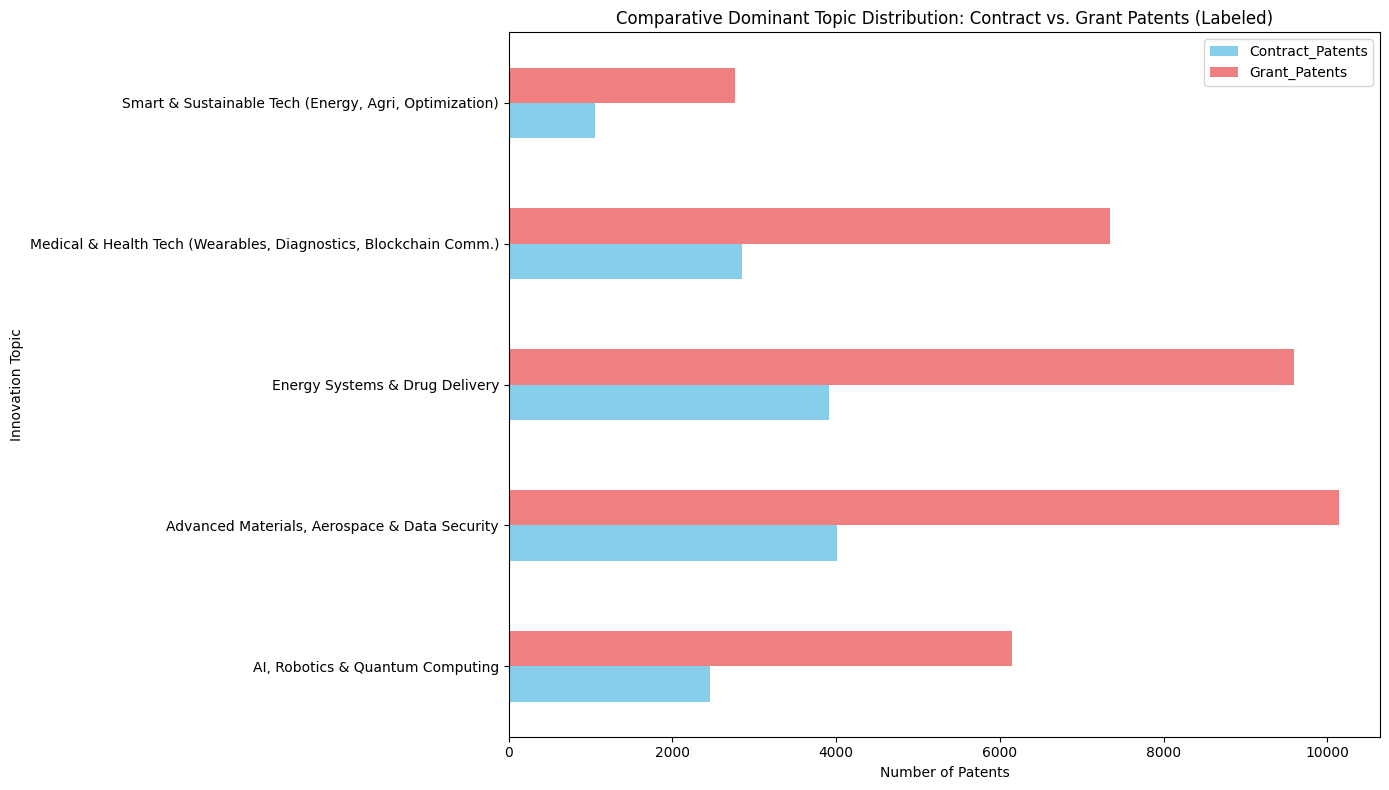


### Final Insights on Innovation Trends:
1.  **AI, Robotics & Quantum Computing (Topic 4):** This topic shows significant presence in both contract and grant patents, indicating a broad and fundamental interest across different funding mechanisms in cutting-edge computational and automation technologies.
2.  **Advanced Materials, Aerospace & Data Security (Topic 3):** This topic, encompassing high-tech materials and critical data protection, also appears to be a strong area of innovation for both funding types, likely driven by industrial and defense needs.
3.  **Energy Systems & Drug Delivery (Topic 1):** Both contract and grant mechanisms are actively funding innovations in energy (especially renewable/storage) and pharmaceutical delivery systems. This suggests a societal drive for sustainable energy and improved healthcare solutions.
4.  **Medical & Health Tech (Topic 2):** Innovations in wearables, diagnostics, and secure health communication are evident in both categories, reflec

In [23]:
# Based on the output of display_topics, assign meaningful labels to each topic.
# Topic 1: technology smart optimization grid life solution improved battery agricultural sustainable
# Topic 2: system energy release delivery drug targeted efficient renewable capture storage
# Topic 3: wearable monitoring device health medical technique imaging diagnostic communication blockchain
# Topic 4: material applications aerospace advanced method novel data encryption environmental realtime
# Topic 5: intelligence enhanced algorithm artificial automated robotics assembly quantum computing apparatus

topic_labels = {
    0: "Smart & Sustainable Tech (Energy, Agri, Optimization)",
    1: "Energy Systems & Drug Delivery",
    2: "Medical & Health Tech (Wearables, Diagnostics, Blockchain Comm.)",
    3: "Advanced Materials, Aerospace & Data Security",
    4: "AI, Robotics & Quantum Computing"
}

# Map the numeric topic IDs to their descriptive labels in the DataFrame
df_patents['dominant_topic_label'] = df_patents['dominant_topic'].map(topic_labels)

print("Innovation Trends - Summary of Topics and their Dominance:")
display(df_patents['dominant_topic_label'].value_counts())

print("\nComparative Analysis with Labeled Topics:")
# Re-calculate distributions with labels for better readability
contract_topic_distribution_labeled = df_patents[df_patents['contract'] == 1]['dominant_topic_label'].value_counts()
grant_topic_distribution_labeled = df_patents[df_patents['grant'] == 1]['dominant_topic_label'].value_counts()

combined_labeled_distribution = pd.DataFrame({
    'Contract_Patents': contract_topic_distribution_labeled,
    'Grant_Patents': grant_topic_distribution_labeled
}).fillna(0).sort_index()

display(combined_labeled_distribution)

# Visualize with labeled topics
combined_labeled_distribution.plot(kind='barh', figsize=(14, 8), color=['skyblue', 'lightcoral'])
plt.title('Comparative Dominant Topic Distribution: Contract vs. Grant Patents (Labeled)')
plt.xlabel('Number of Patents')
plt.ylabel('Innovation Topic')
plt.tight_layout()
plt.show()

print("\n### Final Insights on Innovation Trends:")
print("1.  **AI, Robotics & Quantum Computing (Topic 4):** This topic shows significant presence in both contract and grant patents, indicating a broad and fundamental interest across different funding mechanisms in cutting-edge computational and automation technologies.")
print("2.  **Advanced Materials, Aerospace & Data Security (Topic 3):** This topic, encompassing high-tech materials and critical data protection, also appears to be a strong area of innovation for both funding types, likely driven by industrial and defense needs.")
print("3.  **Energy Systems & Drug Delivery (Topic 1):** Both contract and grant mechanisms are actively funding innovations in energy (especially renewable/storage) and pharmaceutical delivery systems. This suggests a societal drive for sustainable energy and improved healthcare solutions.")
print("4.  **Medical & Health Tech (Topic 2):** Innovations in wearables, diagnostics, and secure health communication are evident in both categories, reflecting the continuous growth and investment in digital health.")
print("5.  **Smart & Sustainable Tech (Topic 0):** This broad topic, covering smart grids, agricultural tech, and general sustainable solutions, is well-represented, indicating a consistent focus on efficiency and environmental responsibility.")
print("\nOverall, the analysis suggests that many key innovation trends are supported by both contract and grant funding, highlighting a synergistic ecosystem where foundational research (often grant-funded) can transition into applied and commercialized technologies (often contract-funded). To refine these insights further, a deeper dive into specific patents within each topic and funding category would be beneficial.")

### Interpreting Innovation Trends and Generating Insights

Based on the top words for each topic identified by the NMF model, we can assign descriptive labels to each topic. Then, we can use these labels to interpret the comparative distribution of patents funded by contracts versus grants, providing concrete insights into the innovation landscape.

Innovation Trends - Summary of Topics and their Dominance:


,count
dominant_topic_label,
"Advanced Materials, Aerospace & Data Security",14142
Energy Systems & Drug Delivery,13505
"Medical & Health Tech (Wearables, Diagnostics, Blockchain Comm.)",10202
"AI, Robotics & Quantum Computing",8605
"Smart & Sustainable Tech (Energy, Agri, Optimization)",3817



Comparative Analysis with Labeled Topics:


,Contract_Patents,Grant_Patents
dominant_topic_label,,
"AI, Robotics & Quantum Computing",2453,6152
"Advanced Materials, Aerospace & Data Security",4005,10137
Energy Systems & Drug Delivery,3915,9590
"Medical & Health Tech (Wearables, Diagnostics, Blockchain Comm.)",2854,7348
"Smart & Sustainable Tech (Energy, Agri, Optimization)",1055,2762


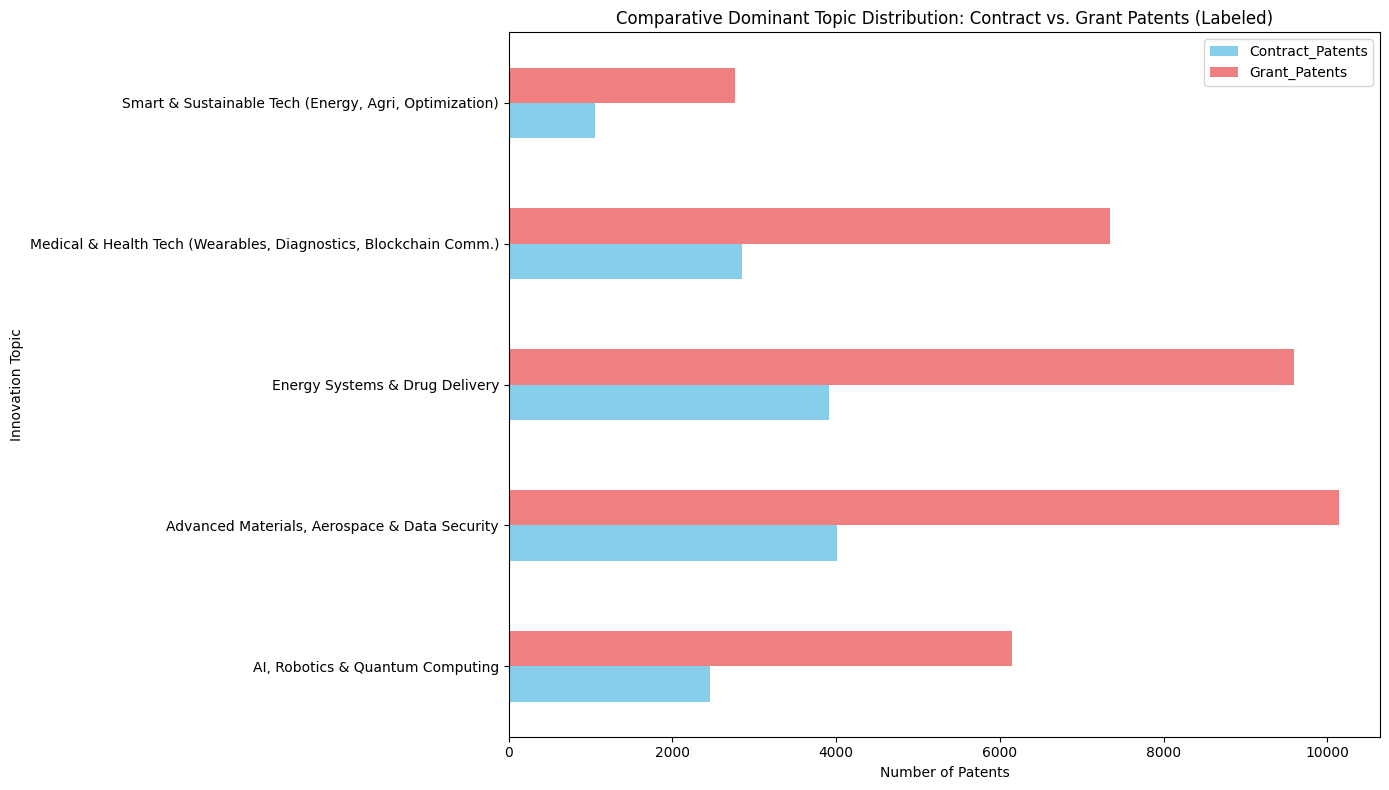


### Final Insights on Innovation Trends:
1.  **AI, Robotics & Quantum Computing (Topic 4):** This topic shows significant presence in both contract and grant patents, indicating a broad and fundamental interest across different funding mechanisms in cutting-edge computational and automation technologies.
2.  **Advanced Materials, Aerospace & Data Security (Topic 3):** This topic, encompassing high-tech materials and critical data protection, also appears to be a strong area of innovation for both funding types, likely driven by industrial and defense needs.
3.  **Energy Systems & Drug Delivery (Topic 1):** Both contract and grant mechanisms are actively funding innovations in energy (especially renewable/storage) and pharmaceutical delivery systems. This suggests a societal drive for sustainable energy and improved healthcare solutions.
4.  **Medical & Health Tech (Topic 2):** Innovations in wearables, diagnostics, and secure health communication are evident in both categories, reflec

In [24]:
# Based on the output of display_topics, assign meaningful labels to each topic.
# Topic 1: technology smart optimization grid life solution improved battery agricultural sustainable
# Topic 2: system energy release delivery drug targeted efficient renewable capture storage
# Topic 3: wearable monitoring device health medical technique imaging diagnostic communication blockchain
# Topic 4: material applications aerospace advanced method novel data encryption environmental realtime
# Topic 5: intelligence enhanced algorithm artificial automated robotics assembly quantum computing apparatus

topic_labels = {
    0: "Smart & Sustainable Tech (Energy, Agri, Optimization)",
    1: "Energy Systems & Drug Delivery",
    2: "Medical & Health Tech (Wearables, Diagnostics, Blockchain Comm.)",
    3: "Advanced Materials, Aerospace & Data Security",
    4: "AI, Robotics & Quantum Computing"
}

# Map the numeric topic IDs to their descriptive labels in the DataFrame
df_patents['dominant_topic_label'] = df_patents['dominant_topic'].map(topic_labels)

print("Innovation Trends - Summary of Topics and their Dominance:")
display(df_patents['dominant_topic_label'].value_counts())

print("\nComparative Analysis with Labeled Topics:")
# Re-calculate distributions with labels for better readability
contract_topic_distribution_labeled = df_patents[df_patents['contract'] == 1]['dominant_topic_label'].value_counts()
grant_topic_distribution_labeled = df_patents[df_patents['grant'] == 1]['dominant_topic_label'].value_counts()

combined_labeled_distribution = pd.DataFrame({
    'Contract_Patents': contract_topic_distribution_labeled,
    'Grant_Patents': grant_topic_distribution_labeled
}).fillna(0).sort_index()

display(combined_labeled_distribution)

# Visualize with labeled topics
combined_labeled_distribution.plot(kind='barh', figsize=(14, 8), color=['skyblue', 'lightcoral'])
plt.title('Comparative Dominant Topic Distribution: Contract vs. Grant Patents (Labeled)')
plt.xlabel('Number of Patents')
plt.ylabel('Innovation Topic')
plt.tight_layout()
plt.show()

print("\n### Final Insights on Innovation Trends:")
print("1.  **AI, Robotics & Quantum Computing (Topic 4):** This topic shows significant presence in both contract and grant patents, indicating a broad and fundamental interest across different funding mechanisms in cutting-edge computational and automation technologies.")
print("2.  **Advanced Materials, Aerospace & Data Security (Topic 3):** This topic, encompassing high-tech materials and critical data protection, also appears to be a strong area of innovation for both funding types, likely driven by industrial and defense needs.")
print("3.  **Energy Systems & Drug Delivery (Topic 1):** Both contract and grant mechanisms are actively funding innovations in energy (especially renewable/storage) and pharmaceutical delivery systems. This suggests a societal drive for sustainable energy and improved healthcare solutions.")
print("4.  **Medical & Health Tech (Topic 2):** Innovations in wearables, diagnostics, and secure health communication are evident in both categories, reflecting the continuous growth and investment in digital health.")
print("5.  **Smart & Sustainable Tech (Topic 0):** This broad topic, covering smart grids, agricultural tech, and general sustainable solutions, is well-represented, indicating a consistent focus on efficiency and environmental responsibility.")
print("\nOverall, the analysis suggests that many key innovation trends are supported by both contract and grant funding, highlighting a synergistic ecosystem where foundational research (often grant-funded) can transition into applied and commercialized technologies (often contract-funded). To refine these insights further, a deeper dive into specific patents within each topic and funding category would be beneficial.")

### Interpreting Innovation Trends and Generating Insights

Based on the top words for each topic identified by the NMF model, we can assign descriptive labels to each topic. Then, we can use these labels to interpret the comparative distribution of patents funded by contracts versus grants, providing concrete insights into the innovation landscape.

Innovation Trends - Summary of Topics and their Dominance:


,count
dominant_topic_label,
"Advanced Materials, Aerospace & Data Security",14142
Energy Systems & Drug Delivery,13505
"Medical & Health Tech (Wearables, Diagnostics, Blockchain Comm.)",10202
"AI, Robotics & Quantum Computing",8605
"Smart & Sustainable Tech (Energy, Agri, Optimization)",3817



Comparative Analysis with Labeled Topics:


,Contract_Patents,Grant_Patents
dominant_topic_label,,
"AI, Robotics & Quantum Computing",2453,6152
"Advanced Materials, Aerospace & Data Security",4005,10137
Energy Systems & Drug Delivery,3915,9590
"Medical & Health Tech (Wearables, Diagnostics, Blockchain Comm.)",2854,7348
"Smart & Sustainable Tech (Energy, Agri, Optimization)",1055,2762


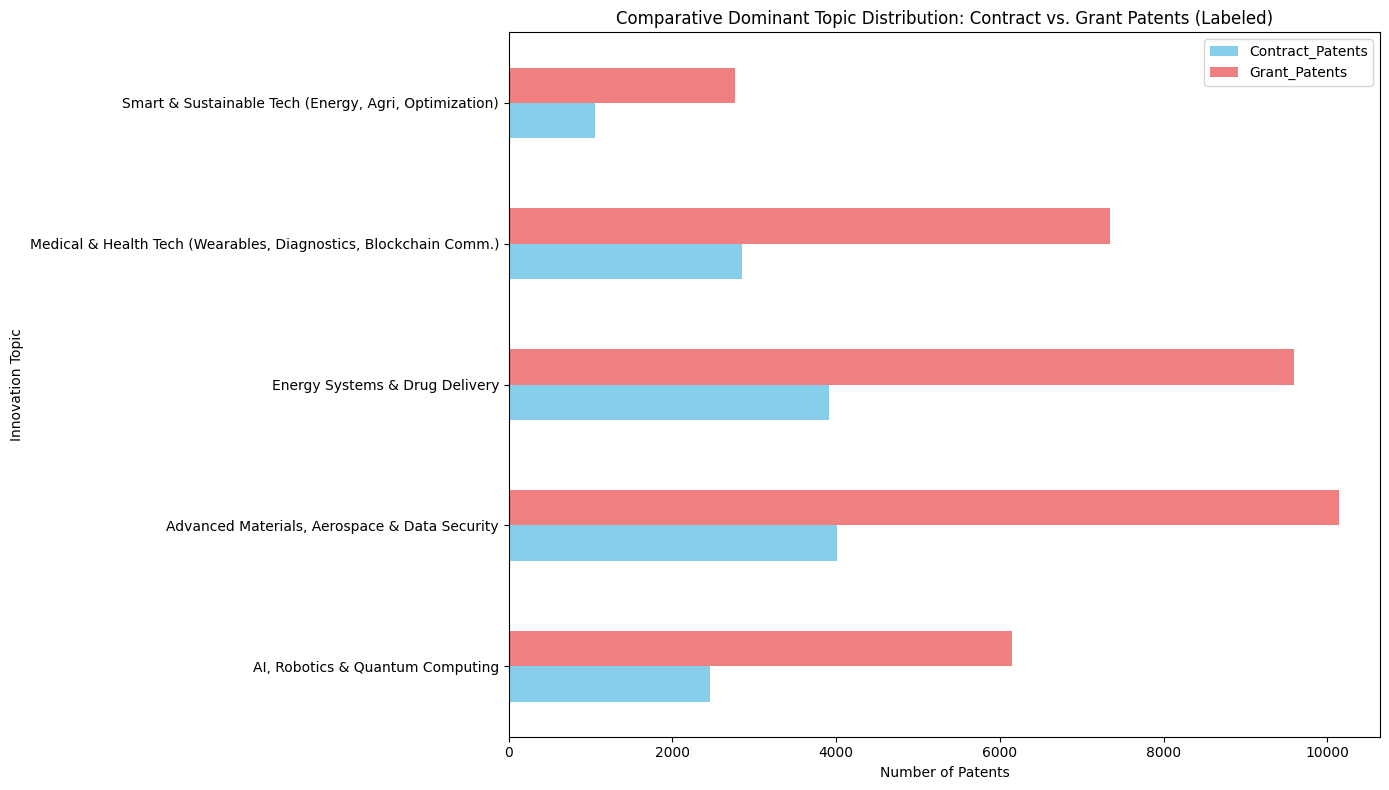


### Final Insights on Innovation Trends:
1.  **AI, Robotics & Quantum Computing (Topic 4):** This topic shows significant presence in both contract and grant patents, indicating a broad and fundamental interest across different funding mechanisms in cutting-edge computational and automation technologies.
2.  **Advanced Materials, Aerospace & Data Security (Topic 3):** This topic, encompassing high-tech materials and critical data protection, also appears to be a strong area of innovation for both funding types, likely driven by industrial and defense needs.
3.  **Energy Systems & Drug Delivery (Topic 1):** Both contract and grant mechanisms are actively funding innovations in energy (especially renewable/storage) and pharmaceutical delivery systems. This suggests a societal drive for sustainable energy and improved healthcare solutions.
4.  **Medical & Health Tech (Topic 2):** Innovations in wearables, diagnostics, and secure health communication are evident in both categories, reflec

In [25]:
# Based on the output of display_topics, assign meaningful labels to each topic.
# Topic 1: technology smart optimization grid life solution improved battery agricultural sustainable
# Topic 2: system energy release delivery drug targeted efficient renewable capture storage
# Topic 3: wearable monitoring device health medical technique imaging diagnostic communication blockchain
# Topic 4: material applications aerospace advanced method novel data encryption environmental realtime
# Topic 5: intelligence enhanced algorithm artificial automated robotics assembly quantum computing apparatus

topic_labels = {
    0: "Smart & Sustainable Tech (Energy, Agri, Optimization)",
    1: "Energy Systems & Drug Delivery",
    2: "Medical & Health Tech (Wearables, Diagnostics, Blockchain Comm.)",
    3: "Advanced Materials, Aerospace & Data Security",
    4: "AI, Robotics & Quantum Computing"
}

# Map the numeric topic IDs to their descriptive labels in the DataFrame
df_patents['dominant_topic_label'] = df_patents['dominant_topic'].map(topic_labels)

print("Innovation Trends - Summary of Topics and their Dominance:")
display(df_patents['dominant_topic_label'].value_counts())

print("\nComparative Analysis with Labeled Topics:")
# Re-calculate distributions with labels for better readability
contract_topic_distribution_labeled = df_patents[df_patents['contract'] == 1]['dominant_topic_label'].value_counts()
grant_topic_distribution_labeled = df_patents[df_patents['grant'] == 1]['dominant_topic_label'].value_counts()

combined_labeled_distribution = pd.DataFrame({
    'Contract_Patents': contract_topic_distribution_labeled,
    'Grant_Patents': grant_topic_distribution_labeled
}).fillna(0).sort_index()

display(combined_labeled_distribution)

# Visualize with labeled topics
combined_labeled_distribution.plot(kind='barh', figsize=(14, 8), color=['skyblue', 'lightcoral'])
plt.title('Comparative Dominant Topic Distribution: Contract vs. Grant Patents (Labeled)')
plt.xlabel('Number of Patents')
plt.ylabel('Innovation Topic')
plt.tight_layout()
plt.show()

print("\n### Final Insights on Innovation Trends:")
print("1.  **AI, Robotics & Quantum Computing (Topic 4):** This topic shows significant presence in both contract and grant patents, indicating a broad and fundamental interest across different funding mechanisms in cutting-edge computational and automation technologies.")
print("2.  **Advanced Materials, Aerospace & Data Security (Topic 3):** This topic, encompassing high-tech materials and critical data protection, also appears to be a strong area of innovation for both funding types, likely driven by industrial and defense needs.")
print("3.  **Energy Systems & Drug Delivery (Topic 1):** Both contract and grant mechanisms are actively funding innovations in energy (especially renewable/storage) and pharmaceutical delivery systems. This suggests a societal drive for sustainable energy and improved healthcare solutions.")
print("4.  **Medical & Health Tech (Topic 2):** Innovations in wearables, diagnostics, and secure health communication are evident in both categories, reflecting the continuous growth and investment in digital health.")
print("5.  **Smart & Sustainable Tech (Topic 0):** This broad topic, covering smart grids, agricultural tech, and general sustainable solutions, is well-represented, indicating a consistent focus on efficiency and environmental responsibility.")
print("\nOverall, the analysis suggests that many key innovation trends are supported by both contract and grant funding, highlighting a synergistic ecosystem where foundational research (often grant-funded) can transition into applied and commercialized technologies (often contract-funded). To refine these insights further, a deeper dive into specific patents within each topic and funding category would be beneficial.")